In [ ]:
# initial setup
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


connection = sqlite3.connect("netflix.db")
sql_query = "select * from netflix"
df = pd.read_sql_query(sql_query, connection)
df.head()
connection.close()

In [ ]:
#QUESTION:  To what extent are average daily watch times and monthly fees associated with Netflix customer churn, and which variable has the stronger association?

In [4]:
# recasting data types
df[['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']] = df[['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']].apply(pd.to_numeric)
df = df.astype({'churned': float})
df.dtypes

customer_id                   str
age                         int64
gender                        str
subscription_type             str
watch_hours               float64
last_login_days             int64
region                        str
device                        str
monthly_fee               float64
churned                   float64
payment_method                str
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre                str
dtype: object

In [ ]:
# for values that are impossible, like over 24 hours of netflix watched per day, they are turned null
df[df["avg_watch_time_per_day"] > 24].count()
df.loc[df["avg_watch_time_per_day"] > 24, "avg_watch_time_per_day"] = np.nan
# dropping nulls
df = df.dropna(subset=['avg_watch_time_per_day'])
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
watch_time_group          0
dtype: int64

In [6]:
#find churn rate
ch_rate = (df['churned'].sum()/df['churned'].count())*100.0
unch_rate = (100 - ch_rate)
print('churn rate: ' + str(ch_rate))
print('unchurned rate: ' + str(unch_rate))

churn rate: 50.3
unchurned rate: 49.7


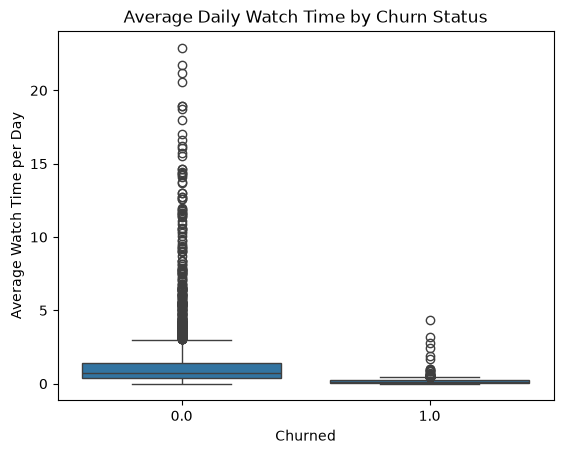

In [ ]:
sns.boxplot(data=df, x='churned', y='avg_watch_time_per_day')

plt.xlabel('Churned')
plt.ylabel('Average Watch Time per Day')
plt.title('Average Daily Watch Time by Churn Status')
plt.show()


# findings: While most people have low daily watch times across the bar, there are a lot of outlying values of customers who don't churn watching a lot. 

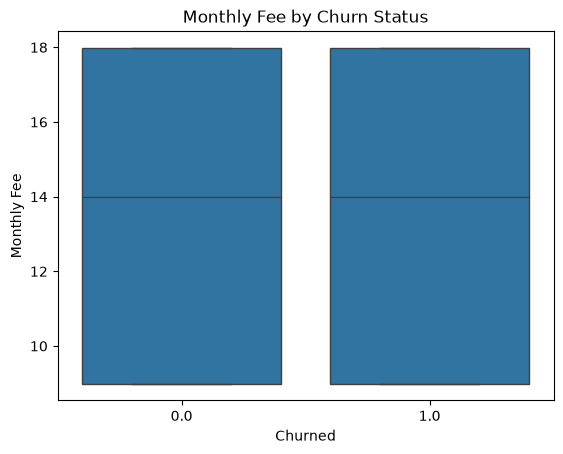

In [ ]:
sns.boxplot(data=df, x='churned', y='monthly_fee')

plt.xlabel('Churned')
plt.ylabel('Monthly Fee')
plt.title('Monthly Fee by Churn Status')
plt.show()

# findings: there is little distinction in distributions in churn status by monthly fee

  watch_time_group    churned
0              Low  91.368174
1           Medium  57.256583
2             High   1.451028


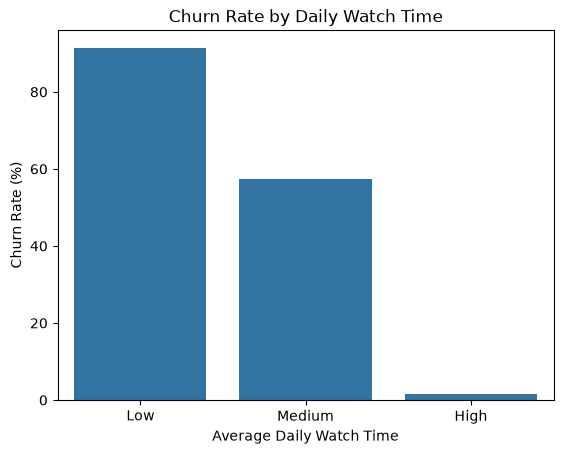

In [44]:
# dividing watch times into 3 categories
df['watch_time_group'] = pd.qcut(
    df['avg_watch_time_per_day'],
    q=3,
    labels=['Low', 'Medium', 'High']
)


# graph
wt_churn_rates = (
    df.groupby('watch_time_group')['churned']
    .mean() # find the averages of each category
    .mul(100) # multiply by 100 to make them percents
    .reset_index() # create a table for seaborn
)

sns.barplot(
    data=wt_churn_rates,
    x='watch_time_group',
    y='churned'
)
print(wt_churn_rates)
plt.xlabel('Average Daily Watch Time')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Daily Watch Time')
plt.show()

# findings: those who have low daily watch times are much more likely to churn

   monthly_fee    churned
0         8.99  61.979481
1        13.99  45.526476
2        17.99  43.786982


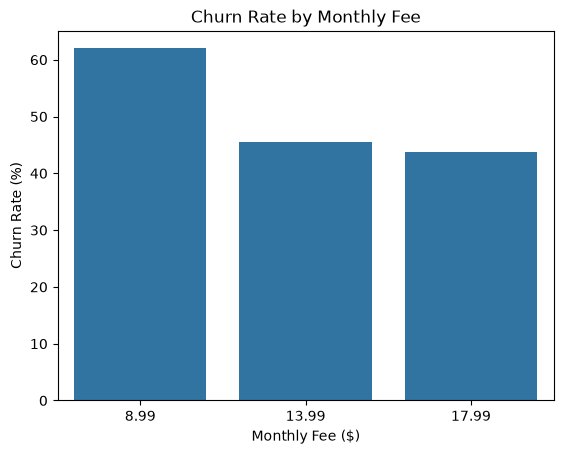

In [43]:
# graph churn rate divided by monthly fees
mf_churn_rates = (
    df.groupby('monthly_fee')['churned']
    .mean() 
    .mul(100) 
    .reset_index() 
)

sns.barplot(
    data=mf_churn_rates,
    x='monthly_fee',
    y='churned'
)
print(mf_churn_rates)
plt.xlabel('Monthly Fee ($)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Monthly Fee')
plt.show()

# findings: customers with the basic subscription are more likely to churn. 

In [22]:
# count, sum, and mean of the average daily watch times
df.groupby('watch_time_group')['churned'].agg(
    ['count', 'sum', 'mean']
)

,count,sum,mean
watch_time_group,,,
Low,1703,1556.0,0.913682
Medium,1633,935.0,0.572566
High,1654,24.0,0.014510


In [13]:
# count, sum, and mean of the monthly fees
df.groupby('monthly_fee')['churned'].agg(
    ['count', 'sum', 'mean']
)

,count,sum,mean
monthly_fee,,,
8.99,1661,1027.0,0.618302
13.99,1646,748.0,0.454435
17.99,1693,740.0,0.437094


In [14]:
# setting up for stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm

In [ ]:
# starting with categorical analysis
# chi square test for average daily watch time
watch_table = pd.crosstab(
    df['watch_time_group'],
    df['churned']
)

chi2, p, dof, expected = chi2_contingency(watch_table)

print("Chi-square:", chi2)
print("p-value:", p)

# findings: p value < 0.05, therefore there is evidence of an association between watch time and liklihood to churn

Chi-square: 2759.4009969102653
p-value: 0.0


In [16]:
# chi square test for monthly fee
fee_table = pd.crosstab(
    df['monthly_fee'],
    df['churned']
)

chi2, p, dof, expected = chi2_contingency(fee_table)

print("Chi-square:", chi2)
print("p-value:", p)

# findings: similar to the avg watch time, p value < 0.05, therefore there is statistical significance

Chi-square: 133.27784242855142
p-value: 1.1457351490503293e-29


In [18]:
# use cramer's v to determine the strength of these relationships
def cramers_v(table):
    x2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, c = table.shape
    return np.sqrt(x2 / (n * min(r - 1, c - 1)))

watch_v = cramers_v(watch_table)
fee_v = cramers_v(fee_table)

print("Watch time Cramer's V:", watch_v)
print("Monthly fee Cramer's V:", fee_v)

#findings: There is a weak correlation between monthly fee and liklihood to churn as Cramer's V for monthly fee is between 0.1 and 0.3. However, there is a strong correlation between average daily watch time and liklihood to churn because its Cramer's V value is 0.7, above 0.5. 

Watch time Cramer's V: 0.7436303999471136
Monthly fee Cramer's V: 0.16326533154871026


In [28]:
# mean, median, and standard deviation of daily watch time and monthly fee, divided by churned vs unchurned
df.groupby("churned")[[
    "avg_watch_time_per_day",
    "monthly_fee"
]].agg(['mean', 'median', 'std'])

# findings: Customers who churn tend to have a lower daily watch time.

avg_watch_time_per_day                  monthly_fee                 
                          mean median       std        mean median       std
churned                                                                     
0.0                   1.443382   0.72  2.310118   14.252626  13.99  3.527195
1.0                   0.164048   0.12  0.186164   13.125189  13.99  3.764869

In [ ]:
# welch's t-test to determine if the churn groups are different
from scipy.stats import ttest_ind

churned = df[df['churned'] == 1]
not_churned = df[df['churned'] == 0]

watch_test = ttest_ind(
    churned['avg_watch_time_per_day'].dropna(),
    not_churned['avg_watch_time_per_day'].dropna(),
    equal_var=False
)

fee_test = ttest_ind(
    churned['monthly_fee'],
    not_churned['monthly_fee'],
    equal_var=False
)

print("Watch time:", watch_test)
print("Monthly fee:", fee_test)

# findings: Because both p-values are below 0.05, there is strong statistical evidence that the mean differs between customers who churn and those who don't. Both tests also have high negative values for the t-test result, meaning there is statistical evidence for those with low fees/low watch times having a higher tendency to churn. 

Watch time: TtestResult(statistic=np.float64(-27.46338236529658), pvalue=np.float64(2.209624254171222e-145), df=np.float64(2505.6223800764874))
Monthly fee: TtestResult(statistic=np.float64(-10.918452750990387), pvalue=np.float64(1.9224970259219177e-27), df=np.float64(4975.99698814547))


In [ ]:
# point-biserial correlation to test the strength of the association between the variables (watch time/fee) versus the churn status

from scipy.stats import pointbiserialr

watch_r, watch_p = pointbiserialr(
    df['churned'],
    df['avg_watch_time_per_day']
)

fee_r, fee_p = pointbiserialr(
    df['churned'],
    df['monthly_fee']
)

print("Watch time")
print("r =", watch_r)
print("p =", watch_p)

print("\nMonthly fee")
print("r =", fee_r)
print("p =", fee_p)

# findings: With low p-values, both results are statistically significant. But with because the absolute value of r for watch time is larger than the value for fee, there is evidence that average daily watch time has a stronger association with churn rates than the monthly fee. 

Watch time
r = -0.3649186245667062
p = 5.045669872296028e-157

Monthly fee
r = -0.15270303847329095
p = 2.0404892886282548e-27


In [ ]:
# Conclusion
  # Descriptive
   # Customers who did not churn had an average daily watch time of 1.44 hours, whereas those who did churn only watched for 0.16 hours. 
   # For monthly fees, those who did not churn paid an average of $14.25 while those who churned paid about $13.12. Both groups however had a median fee of $13.99.
   # Both imply that customers who watch/pay more are less likely to churn. But watch times appears to have a greater difference. 
  # Welch's T-Test
    # According to the low p-value, there appears to be a statistically significant difference between watch times of customers who churn versus those who don't. The high, negative t-value implies that those with low watch times tend to have higher churn rates: t(2505.62) = -27.46, p < 0.001
    # Similar can be said for the monthly fee, with a low p-value and a negative t-value:  t(4976.00) = -10.92, p < 0.001.
  # Point-biserial correlation
    # Average daily watch times have a moderate, negative association with churn (r = -0.365, p < 0.001).
    # Monthly fee also has a negative association, albiet weaker (r = -0.153, p < 0.001).
  # Categorical
   # After dividing average daily watch times into 3 groups, the association between watch time and churn was strong, according to Cramér's V equaling 0.744. Additionally, it is observed that the lower third has a 91.37% chance of churning, middle third has 57.25% and the upper third of watch times has a 1.45% chance of churning.
   # Similar to the conclusion derived from numerical analysis, the value of Cramér's V for monthly fees was 0.163, which is a weaker association. As for the percentages per subscription tier (therefore different monthly fees), the basic tier has a churn rate of 61.98%, standard has a rate of 45.53%, and the premium tier has a 43.78% chance of churning.
  # Limitations
   # For starters, because correlation != causation, it cannot be said that low watch times /cause/ churn. Then, there is the issue of lost information when turning numerics into categories (in the case of the chi square test), which may cause an unnaturally large Cramér's V value. Similarly, there was an unusually strong relationship between watch times and churn, which may bring into question the legitimacy of the data set, which might not actually be reflective of all Netflix customers because of other demographic factors. 
# Final Thoughts
  # Both average daily watch time and monthly fees have a statistically signficant association with churn rate. However, the analysis indicates that watch time has a stronger association and those with low daily watch times were considerably more likely to churn. Though low monthly fees is associated with a higher liklihood to churn as well, the association was considerably weaker. 
  